 ### 1. MERE DATA UNDERSTANDING

In [183]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3
from os.path import exists

In [184]:
conn = sqlite3.connect('../data/im/im.db')
pd.read_sql('''
SELECT name FROM sqlite_master
    WHERE type = 'table'
''',conn)

,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [185]:
movie_basics_df = pd.read_sql("""
    SELECT * FROM movie_basics
""",conn)
movie_basics_df.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [186]:
movie_ratings_df = pd.read_sql("""
       SELECT * FROM movie_ratings
""",conn)
movie_ratings_df

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21
...,...,...,...
73851,tt9805820,8.1,25
73852,tt9844256,7.5,24
73853,tt9851050,4.7,14
73854,tt9886934,7.0,5


In [187]:
df_tn_budgets = pd.read_csv("../data/tn.movie_budgets.csv.gz", compression='gzip')
df_rt_reviews = pd.read_csv("../data/rt.reviews.tsv.gz", compression='gzip',sep='\t',low_memory=False,encoding='latin1')
df_rt_info = pd.read_csv("../data/rt.movie_info.tsv.gz", compression='gzip',sep='\t', low_memory=False)
df_bom_gross = pd.read_csv("../data/bom.movie_gross.csv.gz", compression='gzip')
df_tmdb_movies = pd.read_csv("../data/tmdb.movies.csv.gz", compression='gzip')

In [188]:
df_rt_info.columns

Index(['id', 'synopsis', 'rating', 'genre', 'director', 'writer',
       'theater_date', 'dvd_date', 'currency', 'box_office', 'runtime',
       'studio'],
      dtype='object')

#### 1.1 Data Understanding on tn.movie_budgets

In [189]:
print("\n--- 2. Initial Data Understanding (Raw Data) ---")

print("\n--- df_tn_budgets (Movie Budgets) ---")
df_tn_budgets.head()



--- 2. Initial Data Understanding (Raw Data) ---

--- df_tn_budgets (Movie Budgets) ---


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


In [190]:
df_tn_budgets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   movie              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 271.2+ KB


In [191]:
print("Checking Duplicates for Budget")
df_tn_budgets.duplicated().sum()

Checking Duplicates for Budget


0

In [192]:
print("-------------Missing values\n", df_tn_budgets.isnull().sum())

-------------Missing values
 id                   0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64


#### 1.2 Data Understanding for movies_info

In [193]:
print("\n--- df_rt_info (Rotten Tomatoes Movie Info) ---")
df_rt_info.head(10)


--- df_rt_info (Rotten Tomatoes Movie Info) ---


,id,synopsis,rating,genre,director,writer,theater_date,dvd_date,currency,box_office,runtime,studio
0,1,"This gritty, fast-paced, and innovative police...",R,Action and Adventure|Classics|Drama,William Friedkin,Ernest Tidyman,"Oct 9, 1971","Sep 25, 2001",NaN,NaN,104 minutes,NaN
1,3,"New York City, not-too-distant-future: Eric Pa...",R,Drama|Science Fiction and Fantasy,David Cronenberg,David Cronenberg|Don DeLillo,"Aug 17, 2012","Jan 1, 2013",$,"600,000",108 minutes,Entertainment One
2,5,Illeana Douglas delivers a superb performance ...,R,Drama|Musical and Performing Arts,Allison Anders,Allison Anders,"Sep 13, 1996","Apr 18, 2000",NaN,NaN,116 minutes,NaN
3,6,Michael Douglas runs afoul of a treacherous su...,R,Drama|Mystery and Suspense,Barry Levinson,Paul Attanasio|Michael Crichton,"Dec 9, 1994","Aug 27, 1997",NaN,NaN,128 minutes,NaN
4,7,NaN,NR,Drama|Romance,Rodney Bennett,Giles Cooper,NaN,NaN,NaN,NaN,200 minutes,NaN
5,8,The year is 1942. As the Allies unite overseas...,PG,Drama|Kids and Family,Jay Russell,Gail Gilchriest,"Mar 3, 2000","Jul 11, 2000",NaN,NaN,95 minutes,Warner Bros. Pictures
6,10,Some cast and crew from NBC's highly acclaimed...,PG-13,Comedy,Jake Kasdan,Mike White,"Jan 11, 2002","Jun 18, 2002",$,"41,032,915",82 minutes,Paramount Pictures
7,13,"Stewart Kane, an Irishman living in the Austra...",R,Drama,Ray Lawrence,Raymond Carver|Beatrix Christian,"Apr 27, 2006","Oct 2, 2007",$,"224,114",123 minutes,Sony Pictures Classics
8,14,"""Love Ranch"" is a bittersweet love story that ...",R,Drama,Taylor Hackford,Mark Jacobson,"Jun 30, 2010","Nov 9, 2010",$,"134,904",117 minutes,NaN
9,15,When a diamond expedition in the Congo is lost...,PG-13,Action and Adventure|Mystery and Suspense|Scie...,Frank Marshall,John Patrick Shanley,"Jun 9, 1995","Jul 27, 1999",NaN,NaN,108 minutes,NaN


In [194]:
 df_rt_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1560 entries, 0 to 1559
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            1560 non-null   int64 
 1   synopsis      1498 non-null   object
 2   rating        1557 non-null   object
 3   genre         1552 non-null   object
 4   director      1361 non-null   object
 5   writer        1111 non-null   object
 6   theater_date  1201 non-null   object
 7   dvd_date      1201 non-null   object
 8   currency      340 non-null    object
 9   box_office    340 non-null    object
 10  runtime       1530 non-null   object
 11  studio        494 non-null    object
dtypes: int64(1), object(11)
memory usage: 146.4+ KB


In [195]:
print("Checking duplicates for movies_info")
df_rt_info.duplicated().sum()

Checking duplicates for movies_info


0

In [196]:
print("Missing values:\n", df_rt_info.isnull().sum())

Missing values:
 id                 0
synopsis          62
rating             3
genre              8
director         199
writer           449
theater_date     359
dvd_date         359
currency        1220
box_office      1220
runtime           30
studio          1066
dtype: int64


#### 1.3 Data Understanding for Bom_gross

In [197]:
print("\n--- df_bom_gross (Box Office Mojo Gross) ---")
df_bom_gross.head()


--- df_bom_gross (Box Office Mojo Gross) ---


,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [198]:
df_bom_gross.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


In [199]:
print("Checking duplicates for bom_gross")
df_bom_gross.duplicated().sum()

Checking duplicates for bom_gross


0

In [200]:
print("Missing values:\n", df_bom_gross.isnull().sum())

Missing values:
 title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64


#### 1.4 Data Understanding for Reviews

In [201]:
print("\n--- df_rt_reviews (Rotten Tomatoes Reviews) ---")
df_rt_reviews.head(20)


--- df_rt_reviews (Rotten Tomatoes Reviews) ---


,id,review,rating,fresh,critic,top_critic,publisher,date
0,3,A distinctly gallows take on contemporary fina...,3/5,fresh,PJ Nabarro,0,Patrick Nabarro,"November 10, 2018"
1,3,It's an allegory in search of a meaning that n...,NaN,rotten,Annalee Newitz,0,io9.com,"May 23, 2018"
2,3,... life lived in a bubble in financial dealin...,NaN,fresh,Sean Axmaker,0,Stream on Demand,"January 4, 2018"
3,3,Continuing along a line introduced in last yea...,NaN,fresh,Daniel Kasman,0,MUBI,"November 16, 2017"
4,3,... a perverse twist on neorealism...,NaN,fresh,NaN,0,Cinema Scope,"October 12, 2017"
5,3,... Cronenberg's Cosmopolis expresses somethin...,NaN,fresh,Michelle Orange,0,Capital New York,"September 11, 2017"
6,3,"Quickly grows repetitive and tiresome, meander...",C,rotten,Eric D. Snider,0,EricDSnider.com,"July 17, 2013"
7,3,Cronenberg is not a director to be daunted by ...,2/5,rotten,Matt Kelemen,0,Las Vegas CityLife,"April 21, 2013"
8,3,"Cronenberg's cold, exacting precision and emot...",NaN,fresh,Sean Axmaker,0,Parallax View,"March 24, 2013"
9,3,Over and above its topical urgency or the bit ...,NaN,fresh,Kong Rithdee,0,Bangkok Post,"March 4, 2013"


In [202]:
df_rt_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54432 entries, 0 to 54431
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          54432 non-null  int64 
 1   review      48869 non-null  object
 2   rating      40915 non-null  object
 3   fresh       54432 non-null  object
 4   critic      51710 non-null  object
 5   top_critic  54432 non-null  int64 
 6   publisher   54123 non-null  object
 7   date        54432 non-null  object
dtypes: int64(2), object(6)
memory usage: 3.3+ MB


In [203]:
print("Checking duplicates for reviews")
df_rt_reviews.duplicated().sum()

Checking duplicates for reviews


9

In [204]:
print("Missing values:\n", df_rt_reviews.isnull().sum())

Missing values:
 id                0
review         5563
rating        13517
fresh             0
critic         2722
top_critic        0
publisher       309
date              0
dtype: int64


#### 1.5 Data Understanding for tmdb

In [205]:
print("\n--- df_tmdb_movies (TMDB Movies) ---")
df_tmdb_movies.tail()


--- df_tmdb_movies (TMDB Movies) ---


,Unnamed: 0,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
26512,26512,"[27, 18]",488143,en,Laboratory Conditions,0.6,2018-10-13,Laboratory Conditions,0.0,1
26513,26513,"[18, 53]",485975,en,_EXHIBIT_84xxx_,0.6,2018-05-01,_EXHIBIT_84xxx_,0.0,1
26514,26514,"[14, 28, 12]",381231,en,The Last One,0.6,2018-10-01,The Last One,0.0,1
26515,26515,"[10751, 12, 28]",366854,en,Trailer Made,0.6,2018-06-22,Trailer Made,0.0,1
26516,26516,"[53, 27]",309885,en,The Church,0.6,2018-10-05,The Church,0.0,1


In [206]:
df_tmdb_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26517 entries, 0 to 26516
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         26517 non-null  int64  
 1   genre_ids          26517 non-null  object 
 2   id                 26517 non-null  int64  
 3   original_language  26517 non-null  object 
 4   original_title     26517 non-null  object 
 5   popularity         26517 non-null  float64
 6   release_date       26517 non-null  object 
 7   title              26517 non-null  object 
 8   vote_average       26517 non-null  float64
 9   vote_count         26517 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 2.0+ MB


In [207]:
print("Checking duplicates for tmdb")
df_tmdb_movies.duplicated().sum()

Checking duplicates for tmdb


0

In [208]:
print("Missing values:\n", df_tmdb_movies.isnull().sum())

Missing values:
 Unnamed: 0           0
genre_ids            0
id                   0
original_language    0
original_title       0
popularity           0
release_date         0
title                0
vote_average         0
vote_count           0
dtype: int64


### 2. MERE DATA CLEANING

#### Basically Data Type Conversions and Missing Value Handling

### 2.1 tn_movie_budget 
***Convert currency strings to numeric, and also parsing dates***

In [209]:
print("\nCleaning df_tn_budgets...")
for col in ['production_budget', 'domestic_gross', 'worldwide_gross']:
        if col in df_tn_budgets.columns and df_tn_budgets[col].dtype == 'object':
            df_tn_budgets[col] = df_tn_budgets[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
            df_tn_budgets[col] = pd.to_numeric(df_tn_budgets[col], errors='coerce')


Cleaning df_tn_budgets...


In [210]:
df_tn_budgets['release_date'] = pd.to_datetime(df_tn_budgets['release_date'], errors='coerce')

In [211]:
# Extract release year from tn
df_tn_budgets['release_year'] = df_tn_budgets['release_date'].dt.year

In [212]:
df_tn_budgets = df_tn_budgets[df_tn_budgets['release_year'] > 2010]

In [213]:
df_tn_budgets.release_year.value_counts()

2015    338
2014    255
2011    254
2013    238
2012    235
2016    219
2017    168
2018    143
2019     67
2020      3
Name: release_year, dtype: int64

In [214]:
print("df_tn_budgets after cleaning:")
print()
df_tn_budgets.info()

df_tn_budgets after cleaning:

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1920 entries, 1 to 5780
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 1920 non-null   int64         
 1   release_date       1920 non-null   datetime64[ns]
 2   movie              1920 non-null   object        
 3   production_budget  1920 non-null   int64         
 4   domestic_gross     1920 non-null   int64         
 5   worldwide_gross    1920 non-null   int64         
 6   release_year       1920 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 120.0+ KB


### 2.2 bom_gross
***Convert currency strings to numeric, fill missing 'foreign_gross' with 0.***


***fill missing 'studio' with 'Uknown.***


***drop rows with missing 'domestic_gross***

In [215]:
print("\nCleaning df_bom_gross...")
for col in ['domestic_gross', 'foreign_gross']:
        if col in df_bom_gross.columns and df_bom_gross[col].dtype == 'object':
            df_bom_gross[col] = df_bom_gross[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
            df_bom_gross[col] = pd.to_numeric(df_bom_gross[col], errors='coerce')


Cleaning df_bom_gross...


In [216]:
df_bom_gross.drop(columns='foreign_gross', inplace=True)

In [217]:
if 'studio' in df_bom_gross.columns:
        initial_missing_studio = df_bom_gross['studio'].isnull().sum()
        df_bom_gross['studio'] = df_bom_gross['studio'].fillna('Unknown')
        print(f"Filled {initial_missing_studio} missing 'studio' values with 'Unknown'.")


Filled 5 missing 'studio' values with 'Unknown'.


In [218]:
if 'domestic_gross' in df_bom_gross.columns:
        initial_rows_bom_domestic = len(df_bom_gross)
        df_bom_gross.dropna(subset=['domestic_gross'], inplace=True)
        print(f"df_bom_gross: Dropped {initial_rows_bom_domestic - len(df_bom_gross)} rows due to missing 'domestic_gross'.")

df_bom_gross: Dropped 28 rows due to missing 'domestic_gross'.


In [219]:
print("df_bom_gross after cleaning:")
print()
df_bom_gross.info()

df_bom_gross after cleaning:

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3359 entries, 0 to 3386
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3359 non-null   object 
 1   studio          3359 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   year            3359 non-null   int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 131.2+ KB


In [220]:
print("Missing values after cleaning:\n", df_bom_gross.isnull().sum())

Missing values after cleaning:
 title             0
studio            0
domestic_gross    0
year              0
dtype: int64


### 2.3 movies_info(rt_info)
***Convert 'box_office' to numeric, parse 'theater_date'***

***Convert 'runtime' to numeric and then fill missing***

In [221]:
print("\nCleaning df_rt_info...")
if 'box_office' in df_rt_info.columns and df_rt_info['box_office'].dtype == 'object':
        df_rt_info['box_office'] = df_rt_info['box_office'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
        df_rt_info['box_office'] = pd.to_numeric(df_rt_info['box_office'], errors='coerce')
if 'theater_date' in df_rt_info.columns:
        df_rt_info['theater_date'] = pd.to_datetime(df_rt_info['theater_date'], errors='coerce')


Cleaning df_rt_info...


In [222]:
for col in ['synopsis', 'rating', 'genre', 'director', 'writer', 'studio']:
        if col in df_rt_info.columns:
            initial_missing_count = df_rt_info[col].isnull().sum()
            if initial_missing_count > 0:
                df_rt_info[col] = df_rt_info[col].fillna('Unknown')
                print(f"Filled {initial_missing_count} missing '{col}' values with 'Unknown'.")


Filled 62 missing 'synopsis' values with 'Unknown'.
Filled 3 missing 'rating' values with 'Unknown'.
Filled 8 missing 'genre' values with 'Unknown'.
Filled 199 missing 'director' values with 'Unknown'.
Filled 449 missing 'writer' values with 'Unknown'.
Filled 1066 missing 'studio' values with 'Unknown'.


In [223]:
if 'runtime' in df_rt_info.columns:
        # First, remove " minutes" string if present
        if df_rt_info['runtime'].dtype == 'object':
            df_rt_info['runtime'] = df_rt_info['runtime'].astype(str).str.replace(' minutes', '', regex=False)
        # Convert to numeric, coercing errors (e.g., non-numeric strings) to NaN
        df_rt_info['runtime'] = pd.to_numeric(df_rt_info['runtime'], errors='coerce')
        initial_missing_runtime = df_rt_info['runtime'].isnull().sum()
        if initial_missing_runtime > 0:
            median_runtime = df_rt_info['runtime'].median()
            df_rt_info['runtime'] = df_rt_info['runtime'].fillna(median_runtime)
            print(f"Filled {initial_missing_runtime} missing 'runtime' values with median ({median_runtime}).")


Filled 30 missing 'runtime' values with median (100.0).


In [224]:
print("df_rt_info after cleaning:")
df_rt_info.info()


df_rt_info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1560 entries, 0 to 1559
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            1560 non-null   int64         
 1   synopsis      1560 non-null   object        
 2   rating        1560 non-null   object        
 3   genre         1560 non-null   object        
 4   director      1560 non-null   object        
 5   writer        1560 non-null   object        
 6   theater_date  1201 non-null   datetime64[ns]
 7   dvd_date      1201 non-null   object        
 8   currency      340 non-null    object        
 9   box_office    340 non-null    float64       
 10  runtime       1560 non-null   float64       
 11  studio        1560 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(8)
memory usage: 146.4+ KB


In [225]:
print("Missing values after cleaning:\n", df_rt_info.isnull().sum())

Missing values after cleaning:
 id                 0
synopsis           0
rating             0
genre              0
director           0
writer             0
theater_date     359
dvd_date         359
currency        1220
box_office      1220
runtime            0
studio             0
dtype: int64


In [226]:
df_rt_info.rating.value_counts()

R          521
NR         503
PG         240
PG-13      235
G           57
Unknown      3
NC17         1
Name: rating, dtype: int64

***For the theatre and dvd:These are extra date columns that aren't critical. We already have complete and reliable release date info from release_date_tn (in tn.movie_budgets)***

***For the currency and box office:These are secondary financial details from Rotten Tomatoes. We don’t rely on them for final financial analysis. Instead, we use more complete and prioritized data from tn.movie_budgets and bom.movie_gross for Worldwide_Gross***

### 2.4 Cleaning rt_reviews
***Parsing date.***

***Fill missing 'review' text with a placeholder***

***Fill missing 'rating' with median***

***Fill missing 'critic' and 'publisher' with 'Unknown'***

In [227]:
print("\nCleaning df_rt_reviews...")
if 'date' in df_rt_reviews.columns:
        df_rt_reviews['date'] = pd.to_datetime(df_rt_reviews['date'], errors='coerce')


Cleaning df_rt_reviews...


In [228]:
if 'review' in df_rt_reviews.columns:
        initial_missing_review = df_rt_reviews['review'].isnull().sum()
        if initial_missing_review > 0:
            df_rt_reviews['review'] = df_rt_reviews['review'].fillna('No Review Text')
            print(f"Filled {initial_missing_review} missing 'review' values with 'No Review Text'.")

Filled 5563 missing 'review' values with 'No Review Text'.


In [229]:
df_rt_reviews.publisher.value_counts().head(30)

eFilmCritic.com               673
EmanuelLevy.Com               591
New York Times                590
Washington Post               565
Entertainment Weekly          541
Time Out                      540
Chicago Sun-Times             506
Variety                       497
Austin Chronicle              484
Filmcritic.com                470
rec.arts.movies.reviews       441
Film Threat                   436
TV Guide                      415
Ozus' World Movie Reviews     413
Los Angeles Times             379
Empire Magazine               371
Reeling Reviews               358
San Francisco Chronicle       358
Film Journal International    354
Arkansas Democrat-Gazette     349
One Guy's Opinion             348
ReelViews                     348
Common Sense Media            344
Hollywood Reporter            337
Globe and Mail                334
Boston Globe                  324
Slant Magazine                318
Chicago Reader                311
Chicago Tribune               310
Spirituality a

In [230]:
df_rt_reviews[df_rt_reviews.duplicated()]

,id,review,rating,fresh,critic,top_critic,publisher,date
8129,304,"Friends With Kids is a smart, witty and potty-...",NaN,fresh,NaN,0,Liverpool Echo,2012-06-29
14575,581,No Review Text,4.5/5,fresh,NaN,0,Film Threat,2005-12-06
26226,1055,No Review Text,4/5,fresh,NaN,0,Film Threat,2005-12-06
35162,1368,No Review Text,2/5,rotten,NaN,0,Film Threat,2005-12-06
35166,1368,No Review Text,2/5,rotten,NaN,0,Film Threat,2002-12-08
40567,1535,No Review Text,2/5,rotten,NaN,0,Film Threat,2005-12-06
42381,1598,"This tired, neutered action thriller won't cau...",2/5,rotten,NaN,0,Empire Magazine,2008-11-14
49487,1843,No Review Text,0.5/5,rotten,NaN,0,Film Threat,2005-12-06
49492,1843,No Review Text,0.5/5,rotten,NaN,0,Film Threat,2002-12-08


In [231]:
if all(col in df_rt_reviews.columns for col in ['id', 'review', 'critic','publisher', 'date']):
        initial_rows_rt_reviews = len(df_rt_reviews)
        df_rt_reviews.drop_duplicates(subset=['id', 'review', 'critic','publisher', 'date'])
        print(f"df_rt_reviews: Removed {initial_rows_rt_reviews - len(df_rt_reviews)} duplicates based on 'id', 'review','publisher', 'critic', and 'date'.")
else:
        print("df_rt_reviews: Skipping duplicate check due to missing 'id', 'review', 'critic', or 'date' columns.")

df_rt_reviews: Removed 0 duplicates based on 'id', 'review','publisher', 'critic', and 'date'.


In [232]:
df_rt_reviews.drop(columns='rating', inplace=True)

In [233]:
df_rt_reviews.fresh.value_counts()

fresh     33035
rotten    21397
Name: fresh, dtype: int64

In [234]:
for col in ['critic', 'publisher']:
        if col in df_rt_reviews.columns:
            initial_missing_count = df_rt_reviews[col].isnull().sum()
            if initial_missing_count > 0:
                df_rt_reviews[col] = df_rt_reviews[col].fillna('Unknown ' + col.capitalize())
                print(f"Filled {initial_missing_count} missing '{col}' values with 'Unknown {col.capitalize()}'.")


Filled 2722 missing 'critic' values with 'Unknown Critic'.
Filled 309 missing 'publisher' values with 'Unknown Publisher'.


In [235]:
print("df_rt_reviews after cleaning:")
print()
print(df_rt_reviews.info())
print()
print(f"Duplicates:", df_rt_reviews.duplicated().sum())

df_rt_reviews after cleaning:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54432 entries, 0 to 54431
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          54432 non-null  int64         
 1   review      54432 non-null  object        
 2   fresh       54432 non-null  object        
 3   critic      54432 non-null  object        
 4   top_critic  54432 non-null  int64         
 5   publisher   54432 non-null  object        
 6   date        54432 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 2.9+ MB
None

Duplicates: 25


In [236]:
print("Missing values after cleaning:\n", df_rt_reviews.isnull().sum())

Missing values after cleaning:
 id            0
review        0
fresh         0
critic        0
top_critic    0
publisher     0
date          0
dtype: int64


In [237]:
df_rt_reviews

,id,review,fresh,critic,top_critic,publisher,date
0,3,A distinctly gallows take on contemporary fina...,fresh,PJ Nabarro,0,Patrick Nabarro,2018-11-10
1,3,It's an allegory in search of a meaning that n...,rotten,Annalee Newitz,0,io9.com,2018-05-23
2,3,... life lived in a bubble in financial dealin...,fresh,Sean Axmaker,0,Stream on Demand,2018-01-04
3,3,Continuing along a line introduced in last yea...,fresh,Daniel Kasman,0,MUBI,2017-11-16
4,3,... a perverse twist on neorealism...,fresh,Unknown Critic,0,Cinema Scope,2017-10-12
...,...,...,...,...,...,...,...
54427,2000,The real charm of this trifle is the deadpan c...,fresh,Laura Sinagra,1,Village Voice,2002-09-24
54428,2000,No Review Text,rotten,Michael Szymanski,0,Zap2it.com,2005-09-21
54429,2000,No Review Text,rotten,Emanuel Levy,0,EmanuelLevy.Com,2005-07-17
54430,2000,No Review Text,rotten,Christopher Null,0,Filmcritic.com,2003-09-07


### 2.5 tmbd_movies Cleaning
***Parse 'release_date' column***

In [238]:
df_tmdb_movies['release_date'] = pd.to_datetime(df_tmdb_movies['release_date'], errors='coerce')
df_tmdb_movies['release_year'] = df_tmdb_movies['release_date'].dt.year

In [239]:
print("df_tmdb_movies after cleaning:")
print()
df_tmdb_movies.info()

df_tmdb_movies after cleaning:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26517 entries, 0 to 26516
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         26517 non-null  int64         
 1   genre_ids          26517 non-null  object        
 2   id                 26517 non-null  int64         
 3   original_language  26517 non-null  object        
 4   original_title     26517 non-null  object        
 5   popularity         26517 non-null  float64       
 6   release_date       26517 non-null  datetime64[ns]
 7   title              26517 non-null  object        
 8   vote_average       26517 non-null  float64       
 9   vote_count         26517 non-null  int64         
 10  release_year       26517 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(4), object(4)
memory usage: 2.2+ MB


In [240]:
print("Missing values after cleaning:\n", df_tmdb_movies.isnull().sum())

Missing values after cleaning:
 Unnamed: 0           0
genre_ids            0
id                   0
original_language    0
original_title       0
popularity           0
release_date         0
title                0
vote_average         0
vote_count           0
release_year         0
dtype: int64


### Merging and cleaning the database data

In [241]:
movie_with_ratings = pd.merge(movie_ratings_df,movie_basics_df,left_on='movie_id',right_on='movie_id')
movie_with_ratings.head()

,movie_id,averagerating,numvotes,primary_title,original_title,start_year,runtime_minutes,genres
0,tt10356526,8.3,31,Laiye Je Yaarian,Laiye Je Yaarian,2019,117.0,Romance
1,tt10384606,8.9,559,Borderless,Borderless,2019,87.0,Documentary
2,tt1042974,6.4,20,Just Inès,Just Inès,2010,90.0,Drama
3,tt1043726,4.2,50352,The Legend of Hercules,The Legend of Hercules,2014,99.0,"Action,Adventure,Fantasy"
4,tt1060240,6.5,21,Até Onde?,Até Onde?,2011,73.0,"Mystery,Thriller"


In [242]:
movie_with_ratings.isnull().sum()

movie_id              0
averagerating         0
numvotes              0
primary_title         0
original_title        0
start_year            0
runtime_minutes    7620
genres              804
dtype: int64

In [243]:
movie_with_ratings = movie_with_ratings.dropna()

In [244]:
movie_with_ratings.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 65720 entries, 0 to 73855
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie_id         65720 non-null  object 
 1   averagerating    65720 non-null  float64
 2   numvotes         65720 non-null  int64  
 3   primary_title    65720 non-null  object 
 4   original_title   65720 non-null  object 
 5   start_year       65720 non-null  int64  
 6   runtime_minutes  65720 non-null  float64
 7   genres           65720 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 4.5+ MB


### 3. Feature Engineering
*** Calculate Review_Count from df_rt_reviews***

In [245]:
# Compute Review_Count and Freshness_Score
review_counts = df_rt_reviews.groupby('id').agg(
    Review_Count=('fresh', 'count'),
    Freshness_Score=('fresh', lambda x: (x == 'fresh').sum() / len(x))
).reset_index()

In [246]:
review_counts

,id,Review_Count,Freshness_Score
0,3,163,0.631902
1,5,23,0.782609
2,6,57,0.561404
3,8,75,0.746667
4,10,108,0.462963
...,...,...,...
1130,1996,143,0.671329
1131,1997,28,0.357143
1132,1998,2,1.000000
1133,1999,46,0.586957


In [247]:
review_counts.columns = review_counts.columns.str.lower()

***Merging Reviews and Info***

In [248]:
df_rt_combined = pd.merge(df_rt_info, review_counts, on='id', how='left')
df_rt_combined

,id,synopsis,rating,genre,director,writer,theater_date,dvd_date,currency,box_office,runtime,studio,review_count,freshness_score
0,1,"This gritty, fast-paced, and innovative police...",R,Action and Adventure|Classics|Drama,William Friedkin,Ernest Tidyman,1971-10-09,"Sep 25, 2001",NaN,NaN,104.0,Unknown,NaN,NaN
1,3,"New York City, not-too-distant-future: Eric Pa...",R,Drama|Science Fiction and Fantasy,David Cronenberg,David Cronenberg|Don DeLillo,2012-08-17,"Jan 1, 2013",$,600000.0,108.0,Entertainment One,163.0,0.631902
2,5,Illeana Douglas delivers a superb performance ...,R,Drama|Musical and Performing Arts,Allison Anders,Allison Anders,1996-09-13,"Apr 18, 2000",NaN,NaN,116.0,Unknown,23.0,0.782609
3,6,Michael Douglas runs afoul of a treacherous su...,R,Drama|Mystery and Suspense,Barry Levinson,Paul Attanasio|Michael Crichton,1994-12-09,"Aug 27, 1997",NaN,NaN,128.0,Unknown,57.0,0.561404
4,7,Unknown,NR,Drama|Romance,Rodney Bennett,Giles Cooper,NaT,NaN,NaN,NaN,200.0,Unknown,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1555,1996,Forget terrorists or hijackers -- there's a ha...,R,Action and Adventure|Horror|Mystery and Suspense,Unknown,Unknown,2006-08-18,"Jan 2, 2007",$,33886034.0,106.0,New Line Cinema,143.0,0.671329
1556,1997,The popular Saturday Night Live sketch was exp...,PG,Comedy|Science Fiction and Fantasy,Steve Barron,Terry Turner|Tom Davis|Dan Aykroyd|Bonnie Turner,1993-07-23,"Apr 17, 2001",NaN,NaN,88.0,Paramount Vantage,28.0,0.357143
1557,1998,"Based on a novel by Richard Powell, when the l...",G,Classics|Comedy|Drama|Musical and Performing Arts,Gordon Douglas,Unknown,1962-01-01,"May 11, 2004",NaN,NaN,111.0,Unknown,2.0,1.000000
1558,1999,The Sandlot is a coming-of-age story about a g...,PG,Comedy|Drama|Kids and Family|Sports and Fitness,David Mickey Evans,David Mickey Evans|Robert Gunter,1993-04-01,"Jan 29, 2002",NaN,NaN,101.0,Unknown,46.0,0.586957


In [249]:
df_rt_combined.isnull().sum()

id                    0
synopsis              0
rating                0
genre                 0
director              0
writer                0
theater_date        359
dvd_date            359
currency           1220
box_office         1220
runtime               0
studio                0
review_count        425
freshness_score     425
dtype: int64

In [250]:
# Drop columns with excessive null values EXCEPT review_count and freshness_score
cols_to_drop = ['theater_date', 'dvd_date', 'currency', 'box_office']
df_rt_combined = df_rt_combined.drop(columns=cols_to_drop)

# Fill missing review_count with 0
df_rt_combined['review_count'] = df_rt_combined['review_count'].fillna(0)

# Fill missing freshness_score with median
median_fresh = df_rt_combined['freshness_score'].median()
df_rt_combined['freshness_score'] = df_rt_combined['freshness_score'].fillna(median_fresh)

In [251]:
# Standardize column names to lowercase
df_rt_combined.columns = df_rt_combined.columns.str.lower()

***Merging tmdb and tn_budgets***

In [252]:
#for differentiation I renamed the 'title' to 'tmdb_title' to avoid problems when merging
df_tmdb_movies.rename(columns={'title': 'tmdb_title'}, inplace=True)

In [253]:
# df_tmdb_movies.head(20)

In [254]:
df_tn_budgets.head(20)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,release_year
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000,241063875,1045663875,2011
2,3,2019-06-07,Dark Phoenix,350000000,42762350,149762350,2019
3,4,2015-05-01,Avengers: Age of Ultron,330600000,459005868,1403013963,2015
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000,620181382,1316721747,2017
5,6,2015-12-18,Star Wars Ep. VII: The Force Awakens,306000000,936662225,2053311220,2015
6,7,2018-04-27,Avengers: Infinity War,300000000,678815482,2048134200,2018
8,9,2017-11-17,Justice League,300000000,229024295,655945209,2017
9,10,2015-11-06,Spectre,300000000,200074175,879620923,2015
10,11,2012-07-20,The Dark Knight Rises,275000000,448139099,1084439099,2012
11,12,2018-05-25,Solo: A Star Wars Story,275000000,213767512,393151347,2018


In [255]:
#Renamed movie in tn_budget for easy understanding when merging with tmdb
df_tn_budgets.rename(columns={'movie': 'title'}, inplace=True)

In [256]:
# Standardize title fields in both datasets
df_tn_budgets['title_clean'] = df_tn_budgets['title'].str.lower().str.strip().str.replace(r'[^\w\s]', '', regex=True)
df_tmdb_movies['tmdb_title_clean'] = df_tmdb_movies['tmdb_title'].str.lower().str.strip().str.replace(r'[^\w\s]', '', regex=True)
movie_with_ratings['primary_title_clean'] = movie_with_ratings['primary_title'].str.lower().str.strip().str.replace(r'[^\w\s]', '', regex=True)
# # Merge on the cleaned titles
merged = pd.merge(df_tn_budgets, df_tmdb_movies, left_on=['title_clean'], right_on=['tmdb_title_clean'], how='left')

In [257]:
merged

,id_x,release_date_x,title,production_budget,domestic_gross,worldwide_gross,release_year_x,title_clean,Unnamed: 0,genre_ids,id_y,original_language,original_title,popularity,release_date_y,tmdb_title,vote_average,vote_count,release_year_y,tmdb_title_clean
0,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000,241063875,1045663875,2011,pirates of the caribbean on stranger tides,2470.0,"[12, 28, 14]",1865.0,en,Pirates of the Caribbean: On Stranger Tides,30.579,2011-05-20,Pirates of the Caribbean: On Stranger Tides,6.4,8571.0,2011.0,pirates of the caribbean on stranger tides
1,3,2019-06-07,Dark Phoenix,350000000,42762350,149762350,2019,dark phoenix,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
2,4,2015-05-01,Avengers: Age of Ultron,330600000,459005868,1403013963,2015,avengers age of ultron,14169.0,"[28, 12, 878]",99861.0,en,Avengers: Age of Ultron,44.383,2015-05-01,Avengers: Age of Ultron,7.3,13457.0,2015.0,avengers age of ultron
3,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000,620181382,1316721747,2017,star wars ep viii the last jedi,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
4,6,2015-12-18,Star Wars Ep. VII: The Force Awakens,306000000,936662225,2053311220,2015,star wars ep vii the force awakens,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2234,62,2014-12-31,Stories of Our Lives,15000,0,0,2014,stories of our lives,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
2235,72,2015-05-19,Family Motocross,10000,0,0,2015,family motocross,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
2236,73,2012-01-13,Newlyweds,9000,4584,4584,2012,newlyweds,3468.0,"[35, 10749]",72766.0,en,Newlyweds,1.973,2011-12-26,Newlyweds,5.4,7.0,2011.0,newlyweds
2237,78,2018-12-31,Red 11,7000,0,0,2018,red 11,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN


In [258]:
# Financial and temporal features
merged['Profit'] = merged['worldwide_gross'] - merged['production_budget']
merged['ROI'] = merged['Profit'] / merged['production_budget']
merged['Domestic_vs_Worldwide_Ratio'] = merged['domestic_gross'] / merged['worldwide_gross']
merged['Release_Month'] = merged['release_date_x'].dt.month
merged['Day_of_Week'] = merged['release_date_x'].dt.day_name()
merged['foreign_gross'] = merged['worldwide_gross'] - merged['domestic_gross']

In [259]:
merged.columns

Index(['id_x', 'release_date_x', 'title', 'production_budget',
       'domestic_gross', 'worldwide_gross', 'release_year_x', 'title_clean',
       'Unnamed: 0', 'genre_ids', 'id_y', 'original_language',
       'original_title', 'popularity', 'release_date_y', 'tmdb_title',
       'vote_average', 'vote_count', 'release_year_y', 'tmdb_title_clean',
       'Profit', 'ROI', 'Domestic_vs_Worldwide_Ratio', 'Release_Month',
       'Day_of_Week', 'foreign_gross'],
      dtype='object')

In [260]:
# # Drop suffix columns and low-value metadata
# redundant_cols = [col for col in merged.columns if col.endswith('_x') or col.endswith('_y')]
# low_value_cols = [
#     'id_y', 'tmdb_title', 'original_title', 'original_language',
#     'release_date_y', 'release_date_x',
#     'popularity', 'vote_count', 'vote_average','Unnamed: 0'
# ]
# drop_columns = list(set(redundant_cols + low_value_cols))
# merged.drop(columns=drop_columns, errors='ignore', inplace=True)
# merged.head()

In [261]:
merged.isnull().sum()

id_x                             0
release_date_x                   0
title                            0
production_budget                0
domestic_gross                   0
worldwide_gross                  0
release_year_x                   0
title_clean                      0
Unnamed: 0                     352
genre_ids                      352
id_y                           352
original_language              352
original_title                 352
popularity                     352
release_date_y                 352
tmdb_title                     352
vote_average                   352
vote_count                     352
release_year_y                 352
tmdb_title_clean               352
Profit                           0
ROI                              0
Domestic_vs_Worldwide_Ratio    279
Release_Month                    0
Day_of_Week                      0
foreign_gross                    0
dtype: int64

In [262]:
merged.columns=merged.columns.str.lower()

In [263]:
merged[merged['domestic_vs_worldwide_ratio'].isnull()]

,id_x,release_date_x,title,production_budget,domestic_gross,worldwide_gross,release_year_x,title_clean,unnamed: 0,genre_ids,...,vote_average,vote_count,release_year_y,tmdb_title_clean,profit,roi,domestic_vs_worldwide_ratio,release_month,day_of_week,foreign_gross
142,95,2020-12-31,Moonfall,150000000,0,0,2020,moonfall,NaN,NaN,...,NaN,NaN,NaN,NaN,-150000000,-1.0,NaN,12,Thursday,0
295,80,2017-12-13,Bright,90000000,0,0,2017,bright,20698.0,"[28, 80, 14]",...,6.2,3181.0,2017.0,bright,-90000000,-1.0,NaN,12,Wednesday,0
296,81,2019-12-31,Army of the Dead,90000000,0,0,2019,army of the dead,NaN,NaN,...,NaN,NaN,NaN,NaN,-90000000,-1.0,NaN,12,Tuesday,0
309,36,2020-02-21,Call of the Wild,82000000,0,0,2020,call of the wild,NaN,NaN,...,NaN,NaN,NaN,NaN,-82000000,-1.0,NaN,2,Friday,0
345,71,2019-08-30,PLAYMOBIL,75000000,0,0,2019,playmobil,NaN,NaN,...,NaN,NaN,NaN,NaN,-75000000,-1.0,NaN,8,Friday,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2233,59,2011-11-25,The Ridges,17300,0,0,2011,the ridges,NaN,NaN,...,NaN,NaN,NaN,NaN,-17300,-1.0,NaN,11,Friday,0
2234,62,2014-12-31,Stories of Our Lives,15000,0,0,2014,stories of our lives,NaN,NaN,...,NaN,NaN,NaN,NaN,-15000,-1.0,NaN,12,Wednesday,0
2235,72,2015-05-19,Family Motocross,10000,0,0,2015,family motocross,NaN,NaN,...,NaN,NaN,NaN,NaN,-10000,-1.0,NaN,5,Tuesday,0
2237,78,2018-12-31,Red 11,7000,0,0,2018,red 11,NaN,NaN,...,NaN,NaN,NaN,NaN,-7000,-1.0,NaN,12,Monday,0


In [264]:
merged['domestic_vs_worldwide_ratio'].value_counts() 

1.000000    153
0.000000    134
0.459582      8
0.742428      5
0.418518      5
           ... 
0.620483      1
0.923183      1
0.221028      1
0.183369      1
0.168137      1
Name: domestic_vs_worldwide_ratio, Length: 1409, dtype: int64

***The column Domestic_vs_Worldwide_Ratio has 370 missing values, which means in those rows, either worldwide_gross, domestic_gross, or both were missing or zero .....and dividing by zero isn’t really wise basically.So decided to drop bcz it'll help in actually rolling out data that may be irrelevant in our analysis...basically I mean like having domestic = 923,456,324 and worldwide = 0...so this zii**


In [265]:
merged = merged[merged['domestic_vs_worldwide_ratio'].notnull()]

In [266]:
merged.isnull().sum()

id_x                             0
release_date_x                   0
title                            0
production_budget                0
domestic_gross                   0
worldwide_gross                  0
release_year_x                   0
title_clean                      0
unnamed: 0                     250
genre_ids                      250
id_y                           250
original_language              250
original_title                 250
popularity                     250
release_date_y                 250
tmdb_title                     250
vote_average                   250
vote_count                     250
release_year_y                 250
tmdb_title_clean               250
profit                           0
roi                              0
domestic_vs_worldwide_ratio      0
release_month                    0
day_of_week                      0
foreign_gross                    0
dtype: int64

In [267]:
merged.columns = merged.columns.str.lower()

In [268]:
merged

,id_x,release_date_x,title,production_budget,domestic_gross,worldwide_gross,release_year_x,title_clean,unnamed: 0,genre_ids,...,vote_average,vote_count,release_year_y,tmdb_title_clean,profit,roi,domestic_vs_worldwide_ratio,release_month,day_of_week,foreign_gross
0,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000,241063875,1045663875,2011,pirates of the caribbean on stranger tides,2470.0,"[12, 28, 14]",...,6.4,8571.0,2011.0,pirates of the caribbean on stranger tides,635063875,1.546673,0.230537,5,Friday,804600000
1,3,2019-06-07,Dark Phoenix,350000000,42762350,149762350,2019,dark phoenix,NaN,NaN,...,NaN,NaN,NaN,NaN,-200237650,-0.572108,0.285535,6,Friday,107000000
2,4,2015-05-01,Avengers: Age of Ultron,330600000,459005868,1403013963,2015,avengers age of ultron,14169.0,"[28, 12, 878]",...,7.3,13457.0,2015.0,avengers age of ultron,1072413963,3.243841,0.327157,5,Friday,944008095
3,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000,620181382,1316721747,2017,star wars ep viii the last jedi,NaN,NaN,...,NaN,NaN,NaN,NaN,999721747,3.153696,0.471004,12,Friday,696540365
4,6,2015-12-18,Star Wars Ep. VII: The Force Awakens,306000000,936662225,2053311220,2015,star wars ep vii the force awakens,NaN,NaN,...,NaN,NaN,NaN,NaN,1747311220,5.710167,0.456172,12,Friday,1116648995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2223,38,2016-03-18,Krisha,30000,144822,144822,2016,krisha,14760.0,[18],...,6.8,86.0,2016.0,krisha,114822,3.827400,1.000000,3,Friday,0
2224,38,2016-03-18,Krisha,30000,144822,144822,2016,krisha,18030.0,[18],...,6.8,86.0,2016.0,krisha,114822,3.827400,1.000000,3,Friday,0
2226,45,2017-01-27,Emily,27000,3547,3547,2017,emily,10276.0,[18],...,7.0,1.0,2013.0,emily,-23453,-0.868630,1.000000,1,Friday,0
2227,49,2015-09-01,Exeter,25000,0,489792,2015,exeter,14678.0,"[53, 27]",...,4.7,121.0,2015.0,exeter,464792,18.591680,0.000000,9,Tuesday,489792


### Director and Writer Metrics

In [269]:
review_metrics = df_rt_reviews.groupby('id').agg(
    review_count=('fresh', 'count'),
    freshness_score=('fresh', lambda x: (x == 'fresh').sum() / len(x))
).reset_index()

In [270]:
# Merge review metrics with director and writer
review_metrics_full = pd.merge(df_rt_info[['id', 'director', 'writer']], review_metrics, on='id', how='left')

In [271]:
# Group by director
director_metrics = review_metrics_full.groupby('director').agg(
    director_avg_freshness=('freshness_score', 'mean'),
    director_avg_reviews=('review_count', 'mean'),
    director_movie_count=('id', 'count')
).reset_index()

# Group by writer
writer_metrics = review_metrics_full.groupby('writer').agg(
    writer_avg_freshness=('freshness_score', 'mean'),
    writer_avg_reviews=('review_count', 'mean'),
    writer_movie_count=('id', 'count')
).reset_index()

In [272]:
director_metrics

,director,director_avg_freshness,director_avg_reviews,director_movie_count
0,Abel Ferrara,0.293750,10.5,2
1,Adam Ravetch|Sarah Robertson,0.612903,93.0,1
2,Adam Shankman,0.044118,68.0,1
3,Adam Silver|Ben Hayflick,NaN,NaN,1
4,Aditya Chopra,NaN,NaN,1
...,...,...,...,...
1121,Youssef Delara,0.600000,5.0,1
1122,Yves Simoneau,0.333333,6.0,1
1123,Zak Penn,NaN,NaN,1
1124,Zeresenay Berhane Mehari,0.851852,27.0,1


In [273]:
director_metrics.isnull().sum()

director                    0
director_avg_freshness    282
director_avg_reviews      282
director_movie_count        0
dtype: int64

In [274]:
top_directors_by_reviews = director_metrics.sort_values(by='director_avg_reviews', ascending=False).head(10)
top_directors_by_reviews

,director,director_avg_freshness,director_avg_reviews,director_movie_count
659,Martin McDonagh,0.911243,338.0,1
625,Luca Guadagnino,0.949091,275.0,1
709,Michel Hazanavicius,0.961538,260.0,1
493,Joel Coen|Ethan Coen,0.926923,260.0,1
76,Ava DuVernay,0.988372,258.0,1
727,Morten Tyldum,0.896414,251.0,1
678,Mel Gibson,0.485944,249.0,1
354,Guillermo del Toro,0.717300,237.0,1
1002,Steven Soderbergh,0.926724,232.0,1
935,Sam Mendes,0.795158,218.5,2


In [275]:
top_writers_by_reviews = writer_metrics.sort_values(by='writer_avg_reviews', ascending=False).head(10)
top_writers_by_reviews

,writer,writer_avg_freshness,writer_avg_reviews,writer_movie_count
632,Martin McDonagh,0.911243,338.0,1
423,James Ivory,0.949091,275.0,1
499,John Logan|Robert Wade|Neal Purvis,0.916031,262.0,1
672,Michel Hazanavicius,0.961538,260.0,1
302,Ethan Coen|Joel Coen,0.926923,260.0,1
759,Paul Webb,0.988372,258.0,1
789,Phyllis Nagy,0.941860,258.0,1
359,Graham Moore,0.896414,251.0,1
650,Mel Gibson|Benedict Fitzgerald,0.485944,249.0,1
770,Peter Jackson|Philippa Boyens|Guillermo del To...,0.621399,243.0,1


In [276]:
merged

,id_x,release_date_x,title,production_budget,domestic_gross,worldwide_gross,release_year_x,title_clean,unnamed: 0,genre_ids,...,vote_average,vote_count,release_year_y,tmdb_title_clean,profit,roi,domestic_vs_worldwide_ratio,release_month,day_of_week,foreign_gross
0,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000,241063875,1045663875,2011,pirates of the caribbean on stranger tides,2470.0,"[12, 28, 14]",...,6.4,8571.0,2011.0,pirates of the caribbean on stranger tides,635063875,1.546673,0.230537,5,Friday,804600000
1,3,2019-06-07,Dark Phoenix,350000000,42762350,149762350,2019,dark phoenix,NaN,NaN,...,NaN,NaN,NaN,NaN,-200237650,-0.572108,0.285535,6,Friday,107000000
2,4,2015-05-01,Avengers: Age of Ultron,330600000,459005868,1403013963,2015,avengers age of ultron,14169.0,"[28, 12, 878]",...,7.3,13457.0,2015.0,avengers age of ultron,1072413963,3.243841,0.327157,5,Friday,944008095
3,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000,620181382,1316721747,2017,star wars ep viii the last jedi,NaN,NaN,...,NaN,NaN,NaN,NaN,999721747,3.153696,0.471004,12,Friday,696540365
4,6,2015-12-18,Star Wars Ep. VII: The Force Awakens,306000000,936662225,2053311220,2015,star wars ep vii the force awakens,NaN,NaN,...,NaN,NaN,NaN,NaN,1747311220,5.710167,0.456172,12,Friday,1116648995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2223,38,2016-03-18,Krisha,30000,144822,144822,2016,krisha,14760.0,[18],...,6.8,86.0,2016.0,krisha,114822,3.827400,1.000000,3,Friday,0
2224,38,2016-03-18,Krisha,30000,144822,144822,2016,krisha,18030.0,[18],...,6.8,86.0,2016.0,krisha,114822,3.827400,1.000000,3,Friday,0
2226,45,2017-01-27,Emily,27000,3547,3547,2017,emily,10276.0,[18],...,7.0,1.0,2013.0,emily,-23453,-0.868630,1.000000,1,Friday,0
2227,49,2015-09-01,Exeter,25000,0,489792,2015,exeter,14678.0,"[53, 27]",...,4.7,121.0,2015.0,exeter,464792,18.591680,0.000000,9,Tuesday,489792


In [277]:
merged =merged.merge(movie_with_ratings, left_on='title_clean', right_on='primary_title_clean', how='inner')

In [278]:
merged

,id_x,release_date_x,title,production_budget,domestic_gross,worldwide_gross,release_year_x,title_clean,unnamed: 0,genre_ids,...,foreign_gross,movie_id,averagerating,numvotes,primary_title,original_title_y,start_year,runtime_minutes,genres,primary_title_clean
0,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000,241063875,1045663875,2011,pirates of the caribbean on stranger tides,2470.0,"[12, 28, 14]",...,804600000,tt1298650,6.6,447624,Pirates of the Caribbean: On Stranger Tides,Pirates of the Caribbean: On Stranger Tides,2011,136.0,"Action,Adventure,Fantasy",pirates of the caribbean on stranger tides
1,3,2019-06-07,Dark Phoenix,350000000,42762350,149762350,2019,dark phoenix,NaN,NaN,...,107000000,tt6565702,6.0,24451,Dark Phoenix,Dark Phoenix,2019,113.0,"Action,Adventure,Sci-Fi",dark phoenix
2,4,2015-05-01,Avengers: Age of Ultron,330600000,459005868,1403013963,2015,avengers age of ultron,14169.0,"[28, 12, 878]",...,944008095,tt2395427,7.3,665594,Avengers: Age of Ultron,Avengers: Age of Ultron,2015,141.0,"Action,Adventure,Sci-Fi",avengers age of ultron
3,7,2018-04-27,Avengers: Infinity War,300000000,678815482,2048134200,2018,avengers infinity war,23811.0,"[12, 28, 14]",...,1369318718,tt4154756,8.5,670926,Avengers: Infinity War,Avengers: Infinity War,2018,149.0,"Action,Adventure,Sci-Fi",avengers infinity war
4,9,2017-11-17,Justice League,300000000,229024295,655945209,2017,justice league,20623.0,"[28, 12, 14, 878]",...,426920914,tt0974015,6.5,329135,Justice League,Justice League,2017,120.0,"Action,Adventure,Fantasy",justice league
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2392,38,2016-03-18,Krisha,30000,144822,144822,2016,krisha,14760.0,[18],...,0,tt4266638,7.2,5917,Krisha,Krisha,2015,83.0,Drama,krisha
2393,38,2016-03-18,Krisha,30000,144822,144822,2016,krisha,18030.0,[18],...,0,tt4266638,7.2,5917,Krisha,Krisha,2015,83.0,Drama,krisha
2394,45,2017-01-27,Emily,27000,3547,3547,2017,emily,10276.0,[18],...,0,tt4393036,6.8,13,Emily,Emily,2017,83.0,Drama,emily
2395,49,2015-09-01,Exeter,25000,0,489792,2015,exeter,14678.0,"[53, 27]",...,489792,tt1945044,4.5,5156,Exeter,Exeter,2015,91.0,"Horror,Mystery,Thriller",exeter


In [279]:
#sort dataframe by movies alphabetically
merged = merged.sort_values(by='title_clean', ascending=True)
merged.head()

,id_x,release_date_x,title,production_budget,domestic_gross,worldwide_gross,release_year_x,title_clean,unnamed: 0,genre_ids,...,foreign_gross,movie_id,averagerating,numvotes,primary_title,original_title_y,start_year,runtime_minutes,genres,primary_title_clean
1879,54,2016-03-11,10 Cloverfield Lane,5000000,72082999,108286422,2016,10 cloverfield lane,17422.0,"[53, 878, 18]",...,36203423,tt1179933,7.2,260383,10 Cloverfield Lane,10 Cloverfield Lane,2016,103.0,"Drama,Horror,Mystery",10 cloverfield lane
1556,48,2015-11-11,10 Days in a Madhouse,12000000,14616,14616,2015,10 days in a madhouse,15907.0,[18],...,0,tt3453052,6.7,1114,10 Days in a Madhouse,10 Days in a Madhouse,2015,111.0,Drama,10 days in a madhouse
809,64,2018-01-19,12 Strong,35000000,45819713,71118378,2018,12 strong,24032.0,"[10752, 18, 36, 28]",...,25298665,tt1413492,6.6,50155,12 Strong,12 Strong,2018,130.0,"Action,Drama,History",12 strong
1207,18,2013-10-18,12 Years a Slave,20000000,56671993,181025343,2013,12 years a slave,7911.0,"[18, 36]",...,124353350,tt2024544,8.1,577301,12 Years a Slave,12 Years a Slave,2013,134.0,"Biography,Drama,History",12 years a slave
2040,51,2014-04-18,13 Sins,4000000,9134,47552,2014,13 sins,11150.0,"[27, 53]",...,38418,tt2059171,6.3,29550,13 Sins,13 Sins,2014,93.0,"Horror,Thriller",13 sins


In [280]:
merged = merged.groupby('title_clean')
merged = merged.first()

In [281]:
merged

,id_x,release_date_x,title,production_budget,domestic_gross,worldwide_gross,release_year_x,unnamed: 0,genre_ids,id_y,...,foreign_gross,movie_id,averagerating,numvotes,primary_title,original_title_y,start_year,runtime_minutes,genres,primary_title_clean
title_clean,,,,,,,,,,,,,,,,,,,,,
10 cloverfield lane,54,2016-03-11,10 Cloverfield Lane,5000000,72082999,108286422,2016,17422.0,"[53, 878, 18]",333371.0,...,36203423,tt1179933,7.2,260383,10 Cloverfield Lane,10 Cloverfield Lane,2016,103.0,"Drama,Horror,Mystery",10 cloverfield lane
10 days in a madhouse,48,2015-11-11,10 Days in a Madhouse,12000000,14616,14616,2015,15907.0,[18],345003.0,...,0,tt3453052,6.7,1114,10 Days in a Madhouse,10 Days in a Madhouse,2015,111.0,Drama,10 days in a madhouse
12 strong,64,2018-01-19,12 Strong,35000000,45819713,71118378,2018,24032.0,"[10752, 18, 36, 28]",429351.0,...,25298665,tt1413492,6.6,50155,12 Strong,12 Strong,2018,130.0,"Action,Drama,History",12 strong
12 years a slave,18,2013-10-18,12 Years a Slave,20000000,56671993,181025343,2013,7911.0,"[18, 36]",76203.0,...,124353350,tt2024544,8.1,577301,12 Years a Slave,12 Years a Slave,2013,134.0,"Biography,Drama,History",12 years a slave
13 sins,51,2014-04-18,13 Sins,4000000,9134,47552,2014,11150.0,"[27, 53]",155084.0,...,38418,tt2059171,6.3,29550,13 Sins,13 Sins,2014,93.0,"Horror,Thriller",13 sins
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zero dark thirty,66,2012-12-19,Zero Dark Thirty,52500000,95720716,134612435,2012,5234.0,"[53, 18, 36]",97630.0,...,38891719,tt1790885,7.4,251072,Zero Dark Thirty,Zero Dark Thirty,2012,157.0,"Drama,Thriller",zero dark thirty
zookeeper,71,2011-07-08,Zookeeper,80000000,80360866,170805525,2011,2598.0,"[35, 10749, 10751]",38317.0,...,90444659,tt1222817,5.2,52396,Zookeeper,Zookeeper,2011,102.0,"Comedy,Family,Romance",zookeeper
zoolander 2,64,2016-02-12,Zoolander 2,50000000,28848693,55348693,2016,17483.0,[35],329833.0,...,26500000,tt1608290,4.7,59914,Zoolander 2,Zoolander 2,2016,101.0,Comedy,zoolander 2


In [282]:
#for analysis purposes, change all multiple genre observations into the string "mix"
merged.loc[merged['genres'].str.contains(','), 'genres'] = 'mix'
merged.head()

,id_x,release_date_x,title,production_budget,domestic_gross,worldwide_gross,release_year_x,unnamed: 0,genre_ids,id_y,...,foreign_gross,movie_id,averagerating,numvotes,primary_title,original_title_y,start_year,runtime_minutes,genres,primary_title_clean
title_clean,,,,,,,,,,,,,,,,,,,,,
10 cloverfield lane,54,2016-03-11,10 Cloverfield Lane,5000000,72082999,108286422,2016,17422.0,"[53, 878, 18]",333371.0,...,36203423,tt1179933,7.2,260383,10 Cloverfield Lane,10 Cloverfield Lane,2016,103.0,mix,10 cloverfield lane
10 days in a madhouse,48,2015-11-11,10 Days in a Madhouse,12000000,14616,14616,2015,15907.0,[18],345003.0,...,0,tt3453052,6.7,1114,10 Days in a Madhouse,10 Days in a Madhouse,2015,111.0,Drama,10 days in a madhouse
12 strong,64,2018-01-19,12 Strong,35000000,45819713,71118378,2018,24032.0,"[10752, 18, 36, 28]",429351.0,...,25298665,tt1413492,6.6,50155,12 Strong,12 Strong,2018,130.0,mix,12 strong
12 years a slave,18,2013-10-18,12 Years a Slave,20000000,56671993,181025343,2013,7911.0,"[18, 36]",76203.0,...,124353350,tt2024544,8.1,577301,12 Years a Slave,12 Years a Slave,2013,134.0,mix,12 years a slave
13 sins,51,2014-04-18,13 Sins,4000000,9134,47552,2014,11150.0,"[27, 53]",155084.0,...,38418,tt2059171,6.3,29550,13 Sins,13 Sins,2014,93.0,mix,13 sins


## 2. EXPLORATORY DATA ANALYSIS
 In this section, we will perform Univariate, Bivariate, and Multivariate Analysis with appropriate visualizations for each.

### 2.1 Univariate Analysis

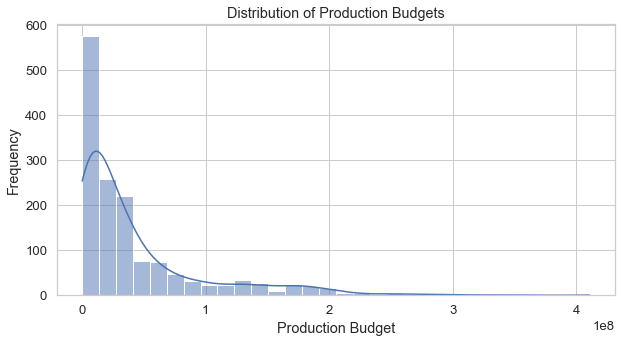

In [283]:
# Distribution of production budgets
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
sns.histplot(merged['production_budget'], bins=30, kde=True)
plt.title('Distribution of Production Budgets')
plt.xlabel('Production Budget')
plt.ylabel('Frequency')
plt.show()

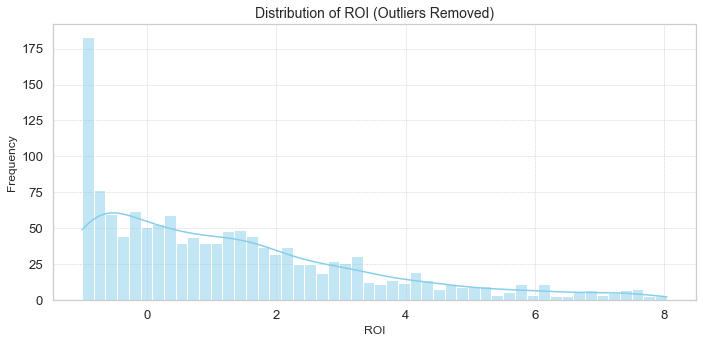

In [284]:
# Step 1: Calculate IQR for ROI
Q1 = merged['roi'].quantile(0.25)
Q3 = merged['roi'].quantile(0.75)
IQR = Q3 - Q1

# Step 2: Define upper and lower bounds for outlier removal
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 3: Filter the DataFrame to remove outliers
df_filtered = merged[(merged['roi'] >= lower_bound) & (merged['roi'] <= upper_bound)]

# Step 4: Plot the histogram without outliers
plt.figure(figsize=(10, 5))
sns.histplot(df_filtered['roi'], bins=50, color='skyblue', kde=True)
plt.title('Distribution of ROI (Outliers Removed)', fontsize=14)
plt.xlabel('ROI', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

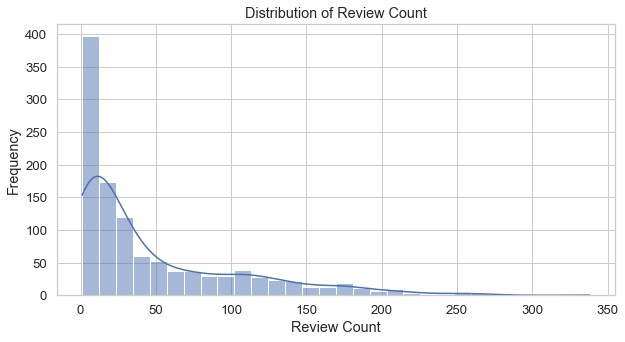

In [285]:
plt.figure(figsize=(10,5))
sns.histplot(review_counts['review_count'], bins=30, kde=True)
plt.title('Distribution of Review Count')
plt.xlabel('Review Count')
plt.ylabel('Frequency')
plt.show()

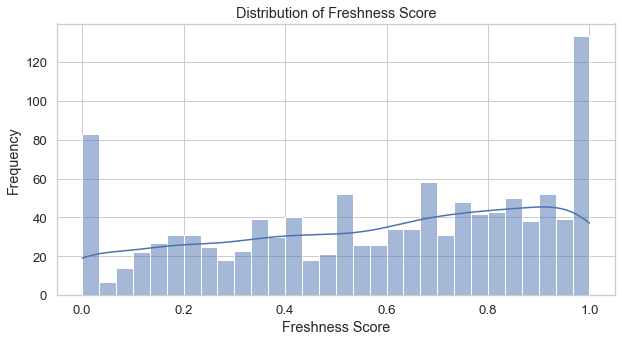

In [286]:
plt.figure(figsize=(10,5))
sns.histplot(review_counts['freshness_score'], bins=30, kde=True)
plt.title('Distribution of Freshness Score')
plt.xlabel('Freshness Score')
plt.ylabel('Frequency')
plt.show()

### Bivariate Analysis

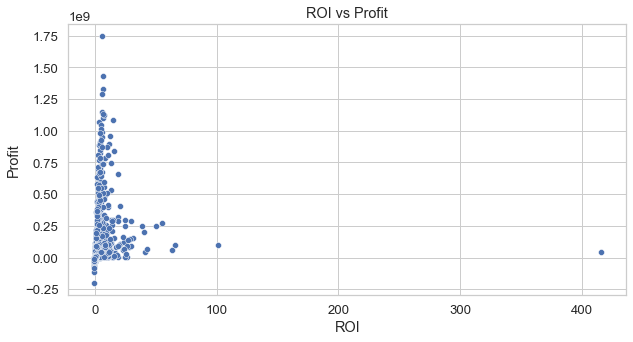

In [287]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=merged['roi'], y=merged['profit'])
plt.title('ROI vs Profit')
plt.xlabel('ROI')
plt.ylabel('Profit')
plt.show()

In [288]:
merged.head()

,id_x,release_date_x,title,production_budget,domestic_gross,worldwide_gross,release_year_x,unnamed: 0,genre_ids,id_y,...,foreign_gross,movie_id,averagerating,numvotes,primary_title,original_title_y,start_year,runtime_minutes,genres,primary_title_clean
title_clean,,,,,,,,,,,,,,,,,,,,,
10 cloverfield lane,54,2016-03-11,10 Cloverfield Lane,5000000,72082999,108286422,2016,17422.0,"[53, 878, 18]",333371.0,...,36203423,tt1179933,7.2,260383,10 Cloverfield Lane,10 Cloverfield Lane,2016,103.0,mix,10 cloverfield lane
10 days in a madhouse,48,2015-11-11,10 Days in a Madhouse,12000000,14616,14616,2015,15907.0,[18],345003.0,...,0,tt3453052,6.7,1114,10 Days in a Madhouse,10 Days in a Madhouse,2015,111.0,Drama,10 days in a madhouse
12 strong,64,2018-01-19,12 Strong,35000000,45819713,71118378,2018,24032.0,"[10752, 18, 36, 28]",429351.0,...,25298665,tt1413492,6.6,50155,12 Strong,12 Strong,2018,130.0,mix,12 strong
12 years a slave,18,2013-10-18,12 Years a Slave,20000000,56671993,181025343,2013,7911.0,"[18, 36]",76203.0,...,124353350,tt2024544,8.1,577301,12 Years a Slave,12 Years a Slave,2013,134.0,mix,12 years a slave
13 sins,51,2014-04-18,13 Sins,4000000,9134,47552,2014,11150.0,"[27, 53]",155084.0,...,38418,tt2059171,6.3,29550,13 Sins,13 Sins,2014,93.0,mix,13 sins


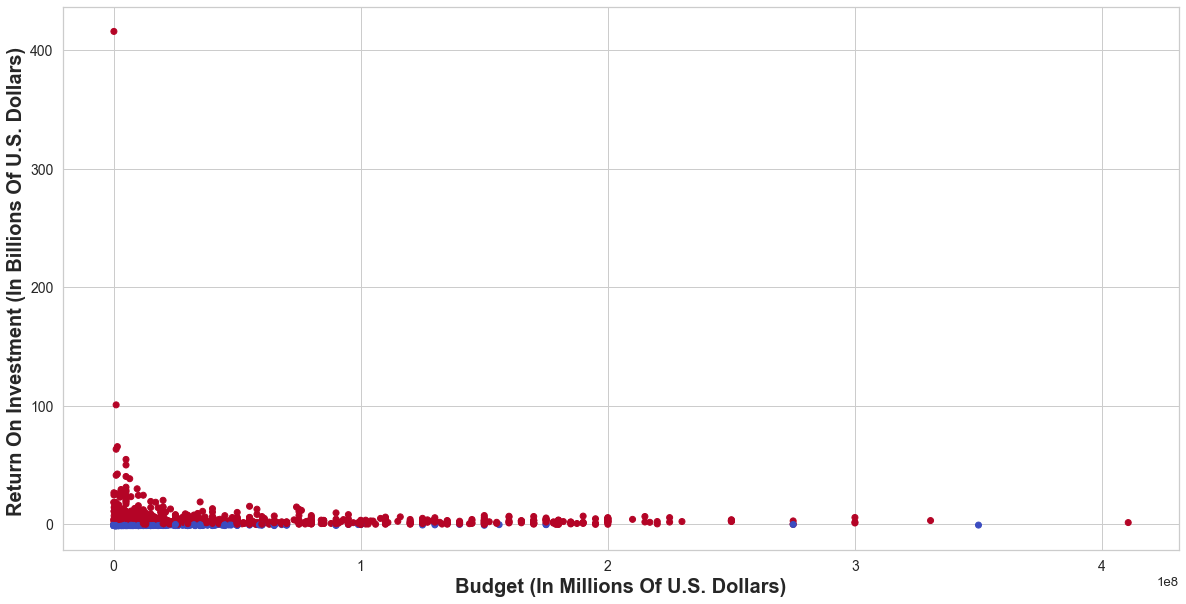

In [289]:
import numpy as np
fig, ax = plt.subplots()
fig.set_size_inches(20,10)
x = merged["production_budget"]
y = merged["roi"]
df = pd.DataFrame({'x': merged["production_budget"], 'y': merged["roi"]})
plt.xlabel('Budget (In Millions Of U.S. Dollars)', fontsize = 20 , weight ='bold')
plt.ylabel('Return On Investment (In Billions Of U.S. Dollars) ', fontsize = 20, weight ='bold')
# plt.title('ROI Vs Budget', fontsize = 17 , weight='bold')
plt.xticks(fontsize=14, rotation=0)
plt.yticks(fontsize=14, rotation=0)
ax.scatter(df.x, df.y, c=np.sign(df.y), cmap="coolwarm")
plt.show()

In [290]:
month_av = merged[['release_month', 'worldwide_gross']]
month_av_grp = month_av.groupby('release_month', as_index=False).mean()
month_av_grp

,release_month,worldwide_gross
0,1,7.621729e+07
1,2,1.198993e+08
2,3,1.324074e+08
3,4,1.104194e+08
4,5,2.124936e+08
5,6,2.101874e+08
6,7,1.852734e+08
7,8,8.722119e+07
8,9,6.744617e+07
9,10,8.353790e+07


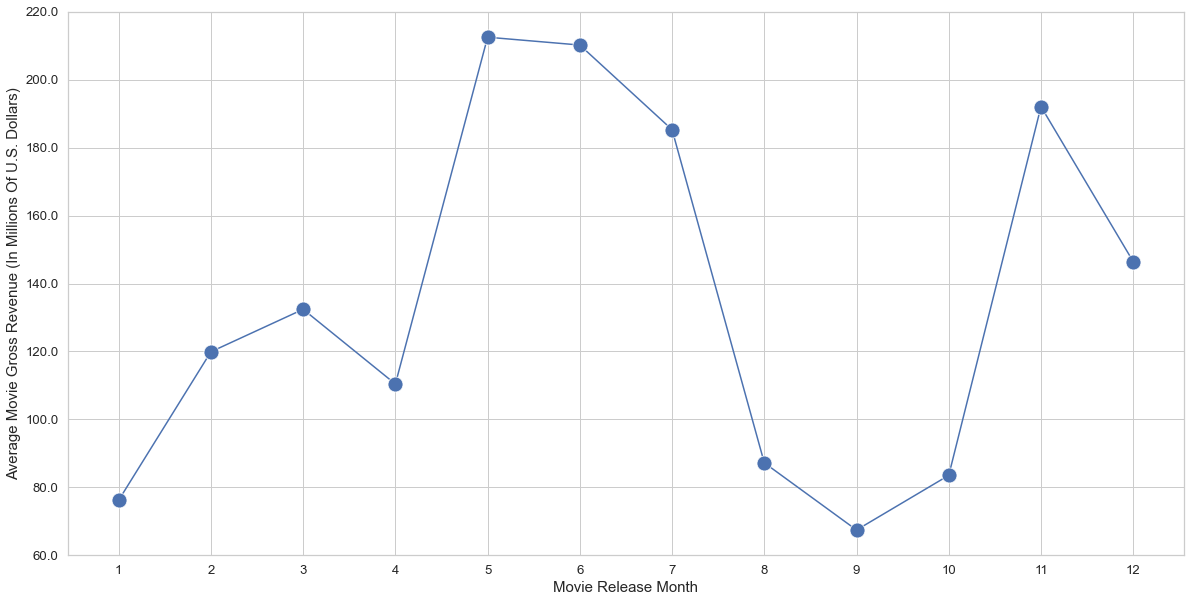

In [291]:
import matplotlib.ticker as ticker
fig, ax = plt.subplots()
fig.set_size_inches(20,10)

ax = sns.lineplot(x="release_month", y="worldwide_gross", marker="o", ci=0, markersize=15, data=month_av_grp)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_major_formatter(ticker.ScalarFormatter(1))
plt.yticks(ax.get_yticks(), ax.get_yticks()/1000000)
plt.ylabel('Average Movie Gross Revenue (In Millions Of U.S. Dollars)', fontsize=15)
plt.xlabel('Movie Release Month', fontsize=15)
sns.set(style='whitegrid', font_scale=1.2)
plt.show()


In [292]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1483 entries, 10 cloverfield lane to zulu
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id_x                         1483 non-null   int64         
 1   release_date_x               1483 non-null   datetime64[ns]
 2   title                        1483 non-null   object        
 3   production_budget            1483 non-null   int64         
 4   domestic_gross               1483 non-null   int64         
 5   worldwide_gross              1483 non-null   int64         
 6   release_year_x               1483 non-null   int64         
 7   unnamed: 0                   1399 non-null   float64       
 8   genre_ids                    1399 non-null   object        
 9   id_y                         1399 non-null   float64       
 10  original_language            1399 non-null   object        
 11  original_title_x             1

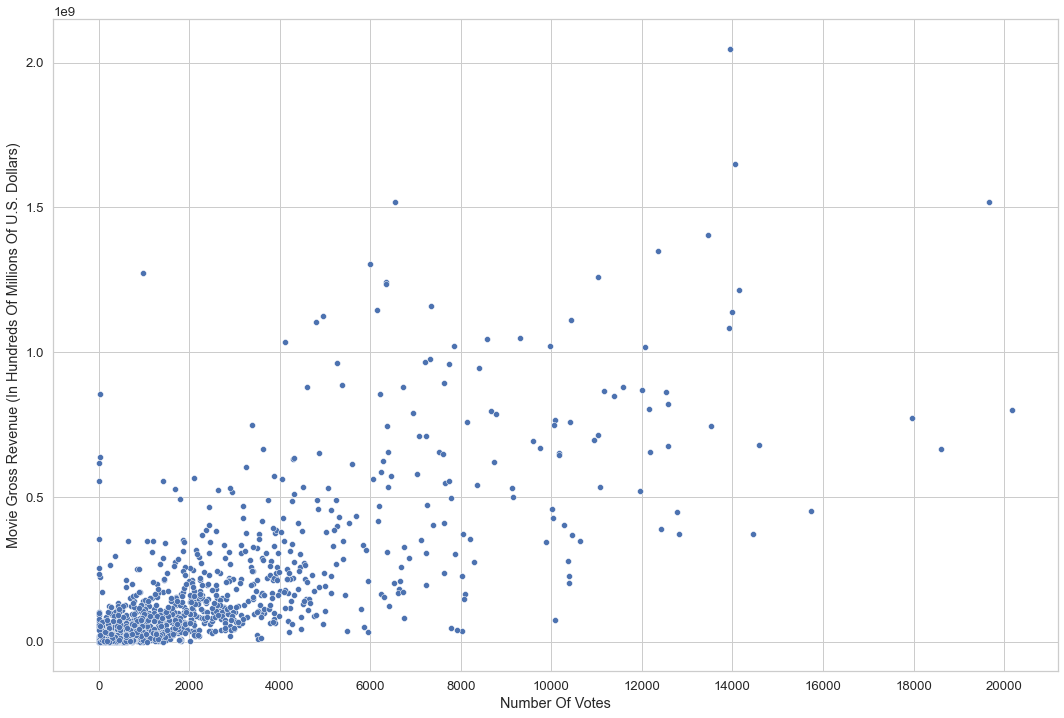

In [293]:
#scatterplot of vote_count vs. worldwide_gross
fig, ax = plt.subplots()
fig.set_size_inches(18,12)

ax = sns.scatterplot(x="vote_count", y="worldwide_gross", marker="o", ci=68, data=merged)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2000))
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set(xlabel='Number Of Votes', ylabel='Movie Gross Revenue (In Hundreds Of Millions Of U.S. Dollars)')
sns.set(style='whitegrid', font_scale=1.5)
plt.show()

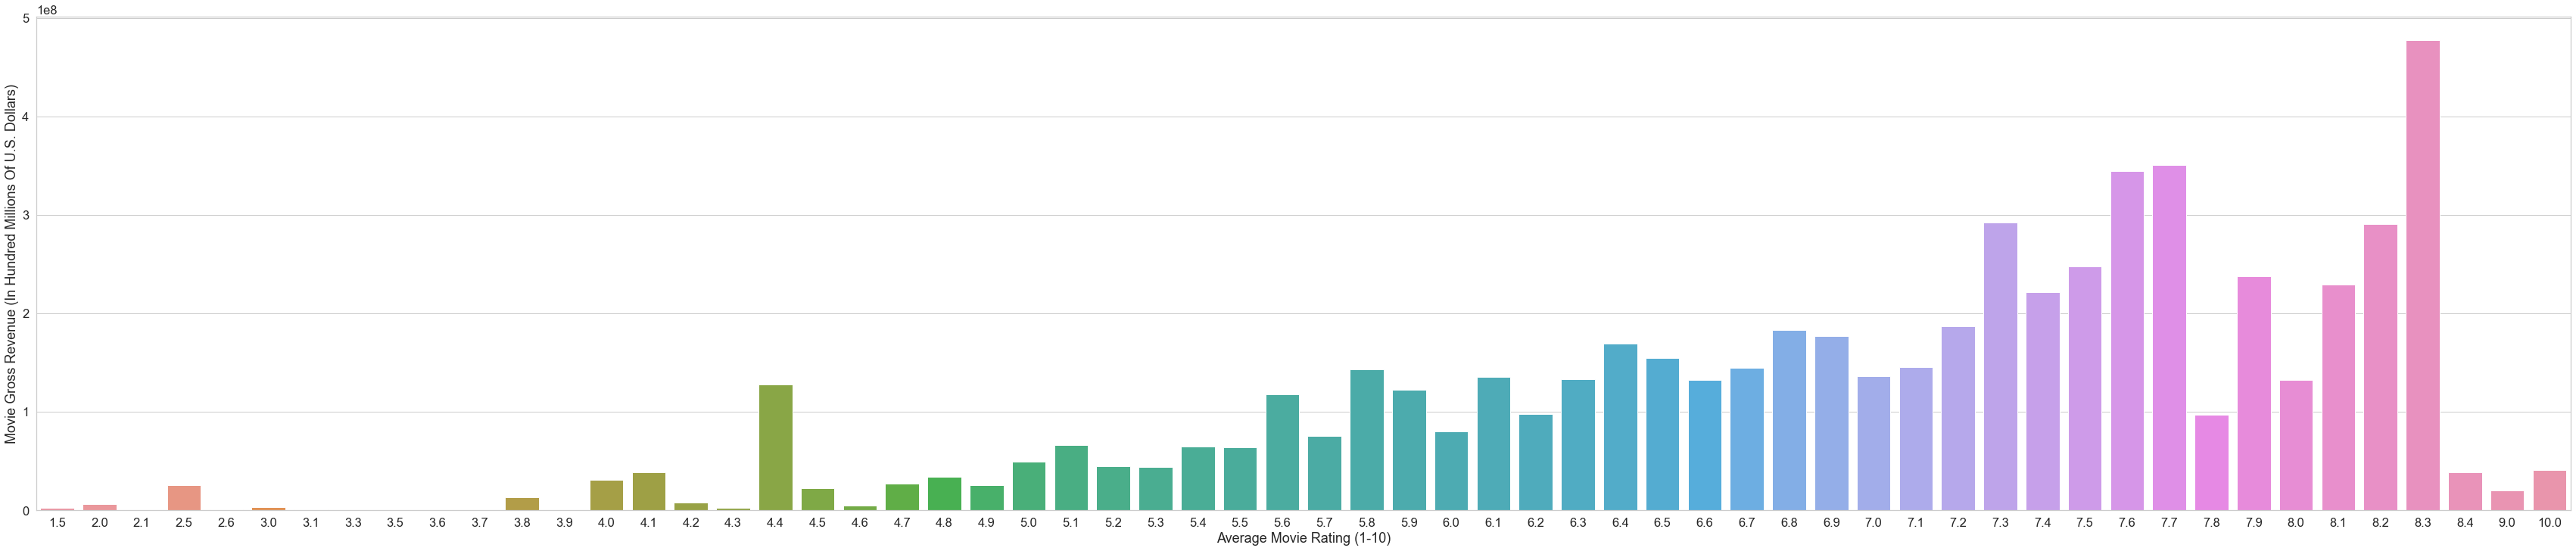

In [294]:
#scatterplot of vote_average vs. worldwide_gross
fig, ax = plt.subplots()
fig.set_size_inches(60,12)

ax = sns.barplot(x="vote_average", y="worldwide_gross", ci=None, data=merged)
ax.set(xlabel='Average Movie Rating (1-10)', ylabel='Movie Gross Revenue (In Hundred Millions Of U.S. Dollars)')
sns.set(style='darkgrid', font_scale=2)
plt.show()

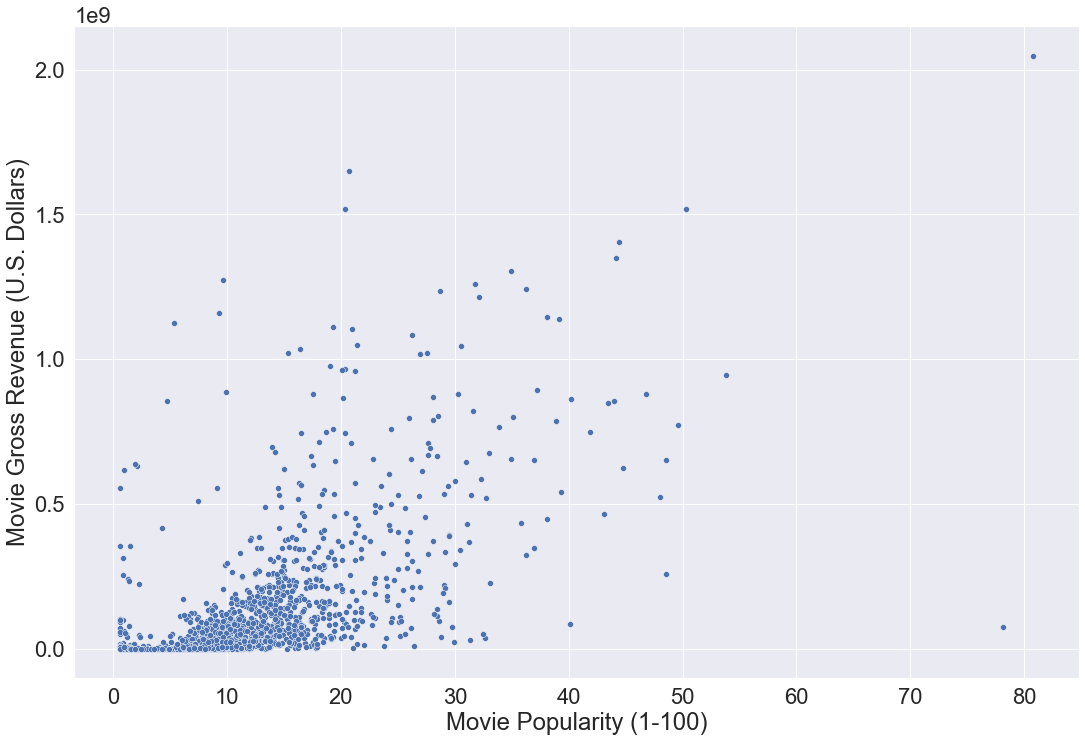

In [295]:
#scatterplot of popularity vs. worldwide_gross
fig, ax = plt.subplots()
fig.set_size_inches(18,12)

ax = sns.scatterplot(x="popularity", y="worldwide_gross", marker="o", ci=68, data=merged)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set(xlabel='Movie Popularity (1-100)', ylabel='Movie Gross Revenue (U.S. Dollars)')
sns.set(style='darkgrid', font_scale=1.5)
plt.show()

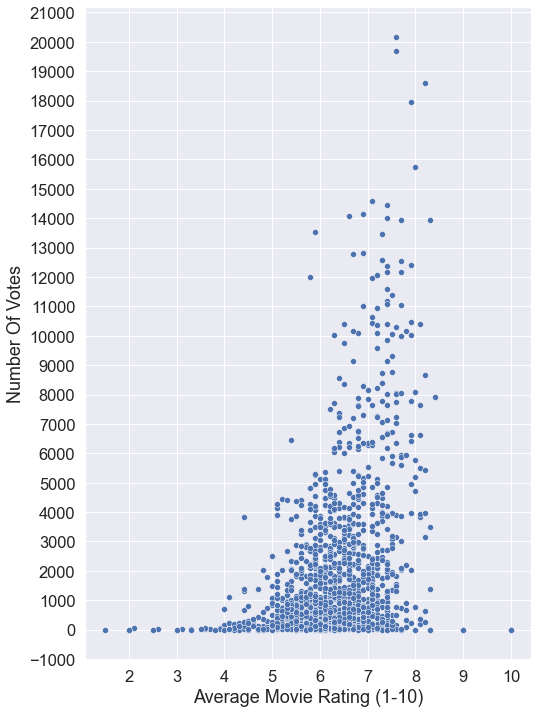

In [296]:
#scatterplot of vote_count vs. vote_average
fig, ax = plt.subplots()
fig.set_size_inches(8,12)

ax = sns.scatterplot(x="vote_average", y="vote_count", marker="o", ci=68, data=merged)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_major_locator(ticker.MultipleLocator(1000))
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set(xlabel='Average Movie Rating (1-10)', ylabel='Number Of Votes')
sns.set(style='whitegrid', font_scale=1.2)
plt.show()

In [297]:
votes_vs_gross = merged[['vote_count', 'vote_average', 'worldwide_gross']]
votes_vs_gross_1000 = votes_vs_gross.loc[votes_vs_gross['vote_count'] >= 1000]
votes_vs_gross_1000 = votes_vs_gross_1000.round(0)
votes_vs_gross_1000

,vote_count,vote_average,worldwide_gross
title_clean,,,
10 cloverfield lane,4629.0,7.0,108286422
12 strong,1312.0,6.0,71118378
12 years a slave,6631.0,8.0,181025343
2 guns,2368.0,6.0,132493015
21 jump street,6527.0,7.0,202812429
...,...,...,...
xxx return of xander cage,2452.0,6.0,345033359
youre next,1258.0,7.0,26887177
zero dark thirty,2553.0,7.0,134612435


In [298]:
votes_vs_gross_1000_grouped = votes_vs_gross_1000.groupby('vote_average', as_index=False).mean()
votes_vs_gross_1000_grouped

,vote_average,vote_count,worldwide_gross
0,4.0,1918.750000,1.007338e+08
1,5.0,2179.970588,1.306948e+08
2,6.0,2801.942953,2.131383e+08
3,7.0,4299.111538,2.788258e+08
4,8.0,6881.584416,3.646947e+08


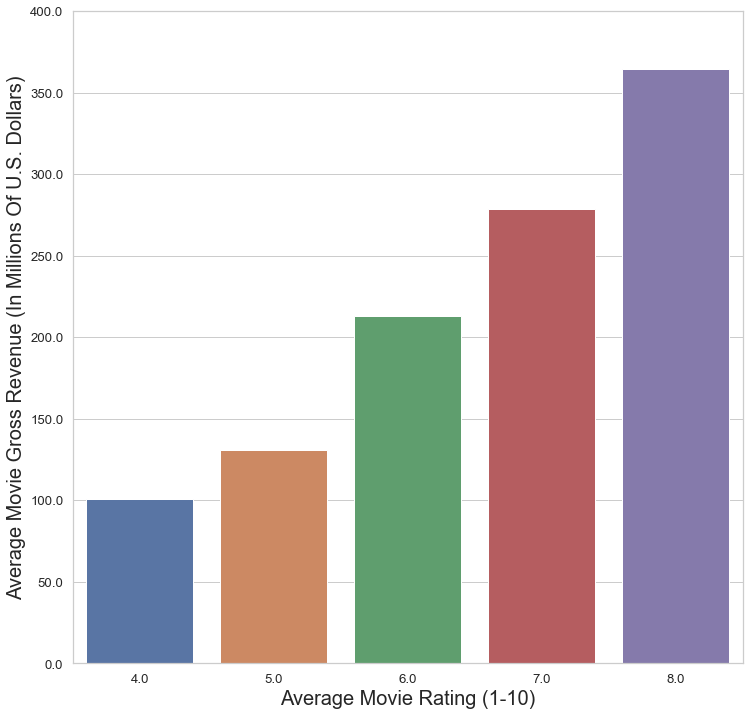

In [299]:
#scatterplot of vote_average, when vote_count is > 1000, vs. worldwide_gross
fig, ax = plt.subplots()
fig.set_size_inches(12,12)

ax = sns.barplot(x="vote_average", y="worldwide_gross", ci=None, data=votes_vs_gross_1000_grouped)
sns.set(style='whitegrid', font_scale=1.2)
sns.set_palette("Reds")
plt.yticks(ax.get_yticks(), ax.get_yticks()/1000000)
plt.ylabel('Average Movie Gross Revenue (In Millions Of U.S. Dollars)', fontsize=20)
plt.xlabel('Average Movie Rating (1-10)', fontsize=20)
plt.show()

In [300]:
genres_avg = merged[['genres', 'worldwide_gross']]
genres_avg_grouped = genres_avg.groupby('genres', as_index=False).mean()
genres_avg_grouped_sorted = genres_avg_grouped.sort_values(by='worldwide_gross', ascending=True)
genres_avg_grouped_sorted

,genres,worldwide_gross
3,Biography,3.925769e+06
11,Sport,5.745503e+06
10,Music,9.082906e+06
8,Fantasy,2.801286e+07
7,Drama,3.385443e+07
0,Action,4.245735e+07
6,Documentary,5.618988e+07
4,Comedy,7.176787e+07
5,Crime,9.962487e+07
9,Horror,1.186939e+08


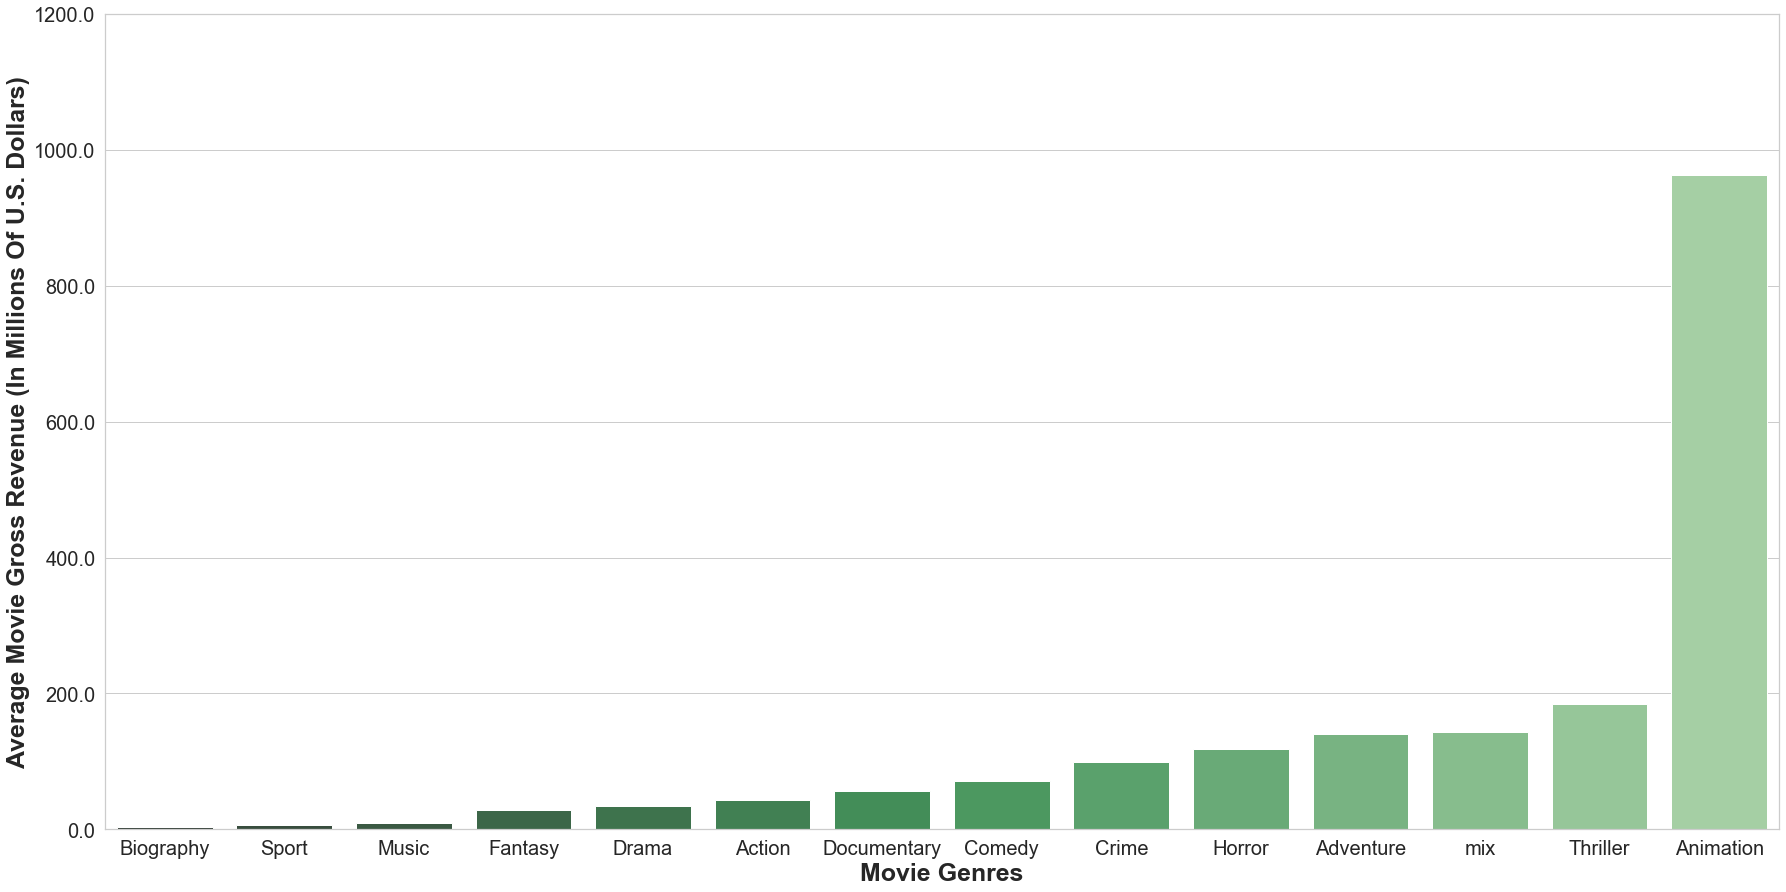

In [301]:
#scatterplot of genres vs. worldwide_gross (average)
sns.set(font_scale = 5)
sns.set(style="whitegrid", color_codes=True)
pal = sns.color_palette("Greens_d", len(genres_avg_grouped_sorted))
fig, ax = plt.subplots()
fig.set_size_inches(30,15)
ax = sns.barplot(x="genres", y="worldwide_gross", ci=None, palette=np.array(pal[::-1]),data=genres_avg_grouped_sorted)
#ax.set(xlabel='Movie Genre', ylabel='Average Movie Gross Revenue (U.S. Dollars)')
plt.xlabel('Movie Genres', fontsize=25, weight = 'bold')
plt.ylabel('Average Movie Gross Revenue (In Millions Of U.S. Dollars)', fontsize=25, weight = 'bold')
plt.yticks(ax.get_yticks(), ax.get_yticks()/1000000)
plt.tick_params(axis='both', which='major', labelsize=20)
#sns.set_style('darkgrid')
plt.show()

In [302]:
import ast
# 1. Create a sample DataFrame with genre_ids as strings
# This simulates the issue where the genre IDs are loaded as a string representation of a list.
data = df_tmdb_movies
tmdb_movies_df = pd.DataFrame(data)

# 2. Define a function to safely convert the string representation of a list to a real list
def parse_genre_ids(genre_ids_string):
    """
    Safely converts a string representation of a list to an actual list.
    Returns an empty list for any invalid input.
    """
    try:
        return ast.literal_eval(genre_ids_string)
    except (ValueError, SyntaxError):
        return []

# 3. Apply the parsing function to fix the data type
tmdb_movies_df['genre_ids'] = tmdb_movies_df['genre_ids'].apply(parse_genre_ids)

# The rest of the code is the same as the previous example to map the IDs to names.
# 4. Create a dictionary to map genre IDs to names
genre_id_to_name = {
    28: 'Action',
    12: 'Adventure',
    16: 'Animation',
    35: 'Comedy',
    80: 'Crime',
    99: 'Documentary',
    18: 'Drama',
    10751: 'Family',
    14: 'Fantasy',
    36: 'History',
    27: 'Horror',
    10402: 'Music',
    9648: 'Mystery',
    10749: 'Romance',
    878: 'Science Fiction',
    10770: 'TV Movie',
    53: 'Thriller',
    10752: 'War',
    37: 'Western'
}

# 5. Define a function to map the IDs to names
def map_genre_ids_to_names(genre_ids_list):
    """
    Maps a list of TMDB genre IDs to their corresponding names.
    Handles multiple genres per movie.
    """
    if isinstance(genre_ids_list, list):
        return [genre_id_to_name.get(gid, 'Unknown') for gid in genre_ids_list]
    return []

# 6. Apply the mapping function to the fixed 'genre_ids' column
tmdb_movies_df['genres'] = tmdb_movies_df['genre_ids'].apply(map_genre_ids_to_names)

# 7. Print the resulting DataFrame
tmdb_movies_df.genres

0                   [Adventure, Fantasy, Family]
1        [Fantasy, Adventure, Animation, Family]
2           [Adventure, Action, Science Fiction]
3                    [Animation, Comedy, Family]
4           [Action, Science Fiction, Adventure]
                          ...                   
26512                            [Horror, Drama]
26513                          [Drama, Thriller]
26514               [Fantasy, Action, Adventure]
26515                [Family, Adventure, Action]
26516                         [Thriller, Horror]
Name: genres, Length: 26517, dtype: object